In [4]:
import os
import json
import zipfile
import subprocess

# ==============================
# KAGGLE SETUP
# ==============================
os.environ['KAGGLE_USERNAME'] = 'ashlinjohnj'
os.environ['KAGGLE_KEY'] = '839c959018a0ec05d364c96c7a85cca1'

kaggle_dir = os.path.expanduser('~/.kaggle')
os.makedirs(kaggle_dir, exist_ok=True)

with open(os.path.join(kaggle_dir, 'kaggle.json'), 'w') as f:
    json.dump({
        "username": os.environ['KAGGLE_USERNAME'],
        "key": os.environ['KAGGLE_KEY']
    }, f)

# ==============================
# DOWNLOAD DATASET
# ==============================
print("Downloading dataset...")
subprocess.run([
    "kaggle", "datasets", "download",
    "-d", "orchit/the-fabrics-dataset-by-ibug",
    "--force"
])

# ==============================
# EXTRACT DATASET
# ==============================
print("Extracting dataset...")
with zipfile.ZipFile("the-fabrics-dataset-by-ibug.zip", 'r') as zip_ref:
    zip_ref.extractall("fabrics_data")

print("Dataset ready!")

Extracting dataset...
Dataset ready!


In [1]:
import numpy as np
import pathlib
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf

print("Dataset setup complete.")

batch_size = 8
img_height = 400
img_width = 400

# FIXED PATH
path = "fabrics_data"
data_dir = pathlib.Path(path)

# ==============================
# LOAD DATA
# ==============================
train_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

val_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

class_names = train_ds.class_names
print(f"Classes found: {class_names}")

# ==============================
# DATA AUGMENTATION
# ==============================
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.5)
])

# ==============================
# PERFORMANCE BOOST
# ==============================
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

# ==============================
# MODEL
# ==============================
num_classes = len(class_names)

model = tf.keras.Sequential([
  data_augmentation,
  tf.keras.layers.Rescaling(1./255),
  tf.keras.layers.Conv2D(32, 3, activation='relu', input_shape=(img_height, img_width, 3)),
  tf.keras.layers.MaxPooling2D(),
  tf.keras.layers.Flatten(),
  tf.keras.layers.Dense(128, activation='relu'),
  tf.keras.layers.Dense(num_classes)
])

model.compile(
  optimizer='adam',
  loss=tf.losses.SparseCategoricalCrossentropy(from_logits=True),
  metrics=['accuracy']
)

model.summary()

# ==============================
# CHECKPOINT
# ==============================
checkpoint_path = "fabric_model.h5"
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_path,
    save_weights_only=False,
    monitor='val_accuracy',
    mode='max',
    save_best_only=True
)

# ==============================
# TRAIN
# ==============================
hist = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    callbacks=[checkpoint]
)

Dataset setup complete.
Found 7885 files belonging to 25 classes.
Using 6308 files for training.
Found 7885 files belonging to 25 classes.
Using 1577 files for validation.
Classes found: ['Acrylic', 'Artificial_fur', 'Artificial_leather', 'Blended', 'Chenille', 'Corduroy', 'Cotton', 'Crepe', 'Denim', 'Felt', 'Fleece', 'Leather', 'Linen', 'Lut', 'Nylon', 'Polyester', 'Satin', 'Silk', 'Suede', 'Terrycloth', 'Unclassified', 'Utilities', 'Velvet', 'Viscose', 'Wool']


C:\Users\ASHLIN\AppData\Roaming\Python\Python39\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

...

Epoch 1/5
789/789 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2641 - loss: 6.1051

789/789 ━━━━━━━━━━━━━━━━━━━━ 1509s 2s/step - accuracy: 0.2642 - loss: 6.1012 - val_accuracy: 0.3253 - val_loss: 2.2427
Epoch 2/5
789/789 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.3072 - loss: 2.2409

789/789 ━━━━━━━━━━━━━━━━━━━━ 2062s 3s/step - accuracy: 0.3072 - loss: 2.2409 - val_accuracy: 0.3456 - val_loss: 2.3261
Epoch 3/5
789/789 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3068 - loss: 2.2427

789/789 ━━━━━━━━━━━━━━━━━━━━ 1350s 2s/step - accuracy: 0.3068 - loss: 2.2427 - val_accuracy: 0.3589 - val_loss: 2.2652
Epoch 4/5
789/789 ━━━━━━━━━━━━━━━━━━━━ 1315s 2s/step - accuracy: 0.3094 - loss: 2.2163 - val_accuracy: 0.3164 - val_loss: 2.3672
Epoch 5/5
789/789 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3139 - loss: 2.1845

789/789 ━━━━━━━━━━━━━━━━━━━━ 1328s 2s/step - accuracy: 0.3139 - loss: 2.1844 - val_accuracy: 0.3729 - val_loss: 2.2941


198/198 ━━━━━━━━━━━━━━━━━━━━ 24s 107ms/step


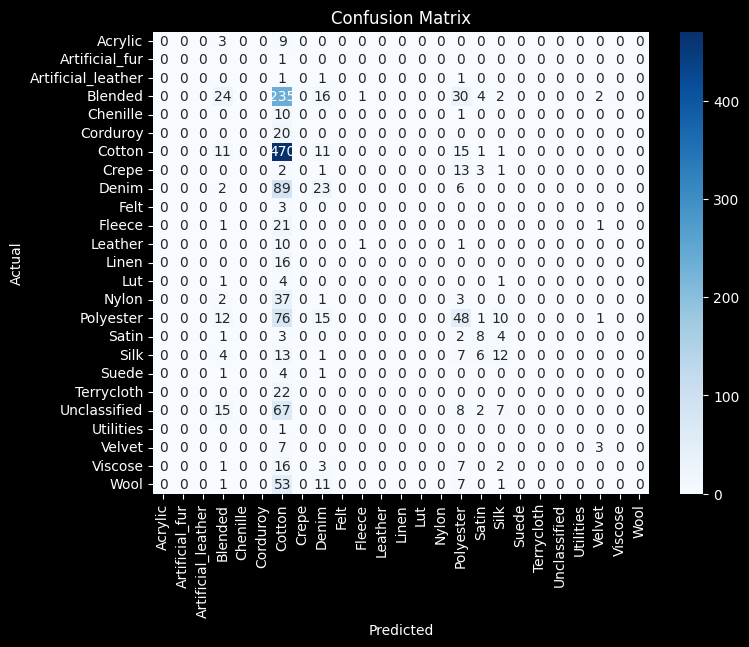

                    precision    recall  f1-score   support

           Acrylic       0.00      0.00      0.00        12
    Artificial_fur       0.00      0.00      0.00         1
Artificial_leather       0.00      0.00      0.00         3
           Blended       0.30      0.08      0.12       314
          Chenille       0.00      0.00      0.00        11
          Corduroy       0.00      0.00      0.00        20
            Cotton       0.39      0.92      0.55       509
             Crepe       0.00      0.00      0.00        20
             Denim       0.27      0.19      0.23       120
              Felt       0.00      0.00      0.00         3
            Fleece       0.00      0.00      0.00        23
           Leather       0.00      0.00      0.00        12
             Linen       0.00      0.00      0.00        16
               Lut       0.00      0.00      0.00         6
             Nylon       0.00      0.00      0.00        43
         Polyester       0.32      0.29

C:\Users\ASHLIN\AppData\Roaming\Python\Python39\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\ASHLIN\AppData\Roaming\Python\Python39\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\ASHLIN\AppData\Roaming\Python\Python39\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} i

In [5]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================
# GET TRUE LABELS
# ==============================
y_true = []
for images, labels in val_ds:
    y_true.extend(labels.numpy())

y_true = np.array(y_true)

# ==============================
# PREDICTIONS
# ==============================
y_pred_probs = model.predict(val_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

# ==============================
# CONFUSION MATRIX
# ==============================
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# ==============================
# CLASSIFICATION REPORT
# ==============================
report = classification_report(y_true, y_pred, target_names=class_names)
print(report)